# 03a Baseline Time Series Models

> Objective: Build a tight classical baseline benchmark for quarterly Credit Reporting complaints and select 1-2 strong baselines using accuracy, runtime, and diagnostics.

## 1. Data Setup
- Dataset: `../data/processed/full_dataset.parquet`
- Scope: total quarterly count where Product contains `Credit reporting`
- Cutoff: up to `2025Q4`
- Split: fixed train/val/test with val and test as equal-sized as possible
- Final horizon: 4 quarters

In [26]:
# ============================================================================
# IMPORT STATEMENTS
# ============================================================================
# Import core libraries for time series analysis, numerical computation, and visualization

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import statsmodels forecasting and diagnostics modules
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

In [27]:
# ============================================================================
# SECTION 1: DATA SETUP
# ============================================================================
# Load quarterly time series data for Credit reporting complaints and create train/val/test splits

cols = ["Product", "year_quarter", "Date received"]
df = pd.read_parquet("../data/processed/full_dataset.parquet", columns=cols)

# Create year_quarter column from Date received if not already present
if "year_quarter" not in df.columns:
    df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
    df["year_quarter"] = df["Date received"].dt.to_period("Q").astype(str)

# Filter to Credit reporting product only
mask_cr = df["Product"].str.contains("Credit reporting", case=False, na=False)
series_df = (
    df.loc[mask_cr]
      .groupby("year_quarter")
      .size()
      .rename("y")
      .to_frame()
      .sort_index()
)
series_df.index = pd.PeriodIndex(series_df.index, freq="Q")
series_df = series_df.loc[:"2025Q4"].copy()
y = series_df["y"].astype(float)

# Create deterministic train/val/test splits
n = len(y)
test_size = max(4, n // 5)  # ≈20% for test, minimum 4 quarters
val_size = test_size  # Equal-sized validation set
while n - (val_size + test_size) < 8 and test_size > 2:  # Ensure minimum training size
    test_size -= 1
    val_size = test_size

train = y.iloc[: n - (val_size + test_size)]
val = y.iloc[n - (val_size + test_size) : n - test_size]
test = y.iloc[n - test_size :]

# Display split summary
print(f"Points: {len(y)} | train={len(train)}, val={len(val)}, test={len(test)}")
print(f"Window: {y.index.min()} -> {y.index.max()}")
display(series_df.tail())

Points: 53 | train=33, val=10, test=10
Window: 2012Q4 -> 2025Q4


,y
year_quarter,
2024Q4,775293
2025Q1,1007034
2025Q2,1094984
2025Q3,1312674
2025Q4,1511343


## 2. Helpers

This section defines reusable utility functions and global state for the forecasting pipeline. We implement three categories of helpers:

1. **Metric Functions** (sMAPE, MAE, RMSE): Standard evaluation metrics for comparing forecast accuracy across all models
2. **Baseline Forecast Functions** (Naive, Moving Average, Seasonal Naive, FFT): Simple, interpretable methods that serve as strong benchmarks
3. **Diagnostics Functions** (spectral entropy, residual diagnostics, plotting): Tools to assess model quality and visualize predictions

These helpers are applied consistently across all model families in Sections 3–7, enabling fair comparison.

In [29]:
# ============================================================================
# SECTION 2: HELPER FUNCTIONS & UTILITIES
# ============================================================================

# ---- Metric Functions ----
def smape(y_true, y_pred):
    """Compute Symmetric Mean Absolute Percentage Error (sMAPE)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    ratio = np.where(denom == 0, 0.0, 2.0 * np.abs(y_true - y_pred) / denom)
    return float(100.0 * np.mean(ratio))

def mae(y_true, y_pred):
    """Compute Mean Absolute Error (MAE)"""
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    """Compute Root Mean Squared Error (RMSE)"""
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

# ---- Baseline Forecast Functions ----
def fc_naive(train_series, h):
    """Naive forecast: repeat last observed value h times"""
    return np.repeat(train_series.iloc[-1], h)

def fc_mavg(train_series, h, k=4):
    """Moving average forecast: repeat the mean of last k values h times"""
    k_eff = min(k, len(train_series))
    return np.repeat(train_series.iloc[-k_eff:].mean(), h)

def fc_snaive(train_series, h, season=4):
    """Seasonal naive forecast: repeat the last seasonal cycle"""
    if len(train_series) < season:
        return fc_naive(train_series, h)
    last_season = train_series.iloc[-season:].values
    reps = int(np.ceil(h / season))
    return np.tile(last_season, reps)[:h]

def fc_fft(train_series, h, keep=6):
    """FFT-based forecast: retain top k frequency components for reconstruction"""
    values = np.asarray(train_series, dtype=float)
    n = len(values)
    x = np.arange(n, dtype=float)

    # Step 1: Remove linear trend before FFT, then add it back after reconstruction
    slope, intercept = np.polyfit(x, values, 1)
    trend = slope * x + intercept
    detr = values - trend

    # Step 2: Compute FFT and identify top k dominant frequencies
    fft_vals = np.fft.rfft(detr)
    amps = np.abs(fft_vals)
    keep = min(keep, len(amps))
    idx = np.argsort(amps)[-keep:]  # Indices of largest amplitudes

    # Step 3: Filter FFT to keep only top k components
    filt = np.zeros_like(fft_vals, dtype=complex)
    filt[idx] = fft_vals[idx]

    # Step 4: Reconstruct signal into future horizon and add back trend
    x_future = np.arange(n + h, dtype=float)
    recon = np.zeros(n + h, dtype=float)
    freqs = np.fft.rfftfreq(n, d=1.0)
    for k, f in enumerate(freqs):
        c = filt[k]
        if np.abs(c) == 0:
            continue
        recon += (2.0 / n) * np.real(c * np.exp(2j * np.pi * f * x_future))

    trend_future = slope * x_future + intercept
    out = recon + trend_future
    return out[-h:]  # Return only future h steps

# ---- Results & Registry Functions ----
def append_result(model_name, val_pred, test_pred, runtime_sec, fit_obj=None):
    """Store model evaluation metrics and predictions in global registry"""
    eval_rows.append({
        "Model": model_name,
        "sMAPE_val": smape(val.values, val_pred),
        "MAE_val": mae(val.values, val_pred),
        "RMSE_val": rmse(val.values, val_pred),
        "sMAPE_test": smape(test.values, test_pred),
        "MAE_test": mae(test.values, test_pred),
        "RMSE_test": rmse(test.values, test_pred),
        "runtime_sec": runtime_sec
    })
    model_registry[model_name] = {
        "fit": fit_obj,
        "val_pred": pd.Series(val_pred, index=val.index, name=model_name),
        "test_pred": pd.Series(test_pred, index=test.index, name=model_name)
    }

# ---- Visualization Functions ----
def plot_section_predictions(section_title, pred_map):
    """Plot observed train/val/test series alongside model predictions for a section"""
    fig, ax = plt.subplots(figsize=(10, 4))

    # Convert period index to timestamp for plotting
    y_train_ts = pd.Series(train.values, index=train.index.to_timestamp(how="end"))
    y_val_ts = pd.Series(val.values, index=val.index.to_timestamp(how="end"))
    y_test_ts = pd.Series(test.values, index=test.index.to_timestamp(how="end"))

    # Plot observed data with different line styles for each period (train/val/test)
    ax.plot(y_train_ts.index, y_train_ts.values, color="steelblue", label="Observed - Train")
    ax.plot(y_val_ts.index, y_val_ts.values, color="steelblue", linestyle="--", alpha=0.8, label="Observed - Val")
    ax.plot(y_test_ts.index, y_test_ts.values, color="steelblue", linestyle=":", alpha=0.9, label="Observed - Test")

    # Overlay model predictions for both val and test periods
    for model_name, preds in pred_map.items():
        val_ts = pd.Series(preds["val"], index=val.index.to_timestamp(how="end"))
        test_ts = pd.Series(preds["test"], index=test.index.to_timestamp(how="end"))
        ax.plot(val_ts.index, val_ts.values, linestyle="--", marker="o", label=f"{model_name} - Val")
        ax.plot(test_ts.index, test_ts.values, marker="o", label=f"{model_name} - Test")

    ax.set_title(section_title)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# ---- Diagnostics Functions ----
def compute_spectral_entropy(series):
    """Compute normalized spectral entropy (0-1 scale; higher = less predictable)"""
    x = np.asarray(series, dtype=float)
    x = x - np.mean(x)  # Center the data
    psd = np.abs(np.fft.rfft(x)) ** 2  # Power Spectral Density
    if psd.sum() == 0:
        return 0.0
    p = psd / psd.sum()  # Normalize to probability distribution
    p = p[p > 0]  # Remove zero probabilities for entropy calculation
    h = -np.sum(p * np.log2(p))  # Shannon entropy
    h_max = np.log2(len(psd)) if len(psd) > 1 else 1.0  # Maximum possible entropy
    return float(h / h_max)  # Normalized entropy

def run_residual_diagnostics(df_results, registry, top_n=2):
    """Extract residual diagnostics (mean, std, Ljung-Box test) for top N models"""
    top_models = df_results.head(top_n)["Model"].tolist()
    rows = []
    for m in top_models:
        fit_obj = registry[m]["fit"]
        if fit_obj is not None and hasattr(fit_obj, "resid"):
            resid = pd.Series(fit_obj.resid).dropna()
            # Ljung-Box test for residual autocorrelation at lag 4 (seasonal)
            lb_p = float(acorr_ljungbox(resid, lags=[4], return_df=True)["lb_pvalue"].iloc[0]) if len(resid) >= 8 else np.nan
            rows.append({
                "Model": m,
                "resid_mean": float(resid.mean()),
                "resid_std": float(resid.std(ddof=1)),
                "ljung_box_p_lag4": lb_p
            })
        else:
            rows.append({
                "Model": m,
                "resid_mean": np.nan,
                "resid_std": np.nan,
                "ljung_box_p_lag4": np.nan
            })
    return pd.DataFrame(rows)

# ---- Global State: Tracking Results & Models ----
eval_rows = []  # List of evaluation metric dicts (populated by each section)
model_registry = {}  # Dict storing fit objects and predictions for all models

## 3. Simple Baselines (Naive, MA, Seasonal Naive)

This section evaluates three simple, deterministic baseline methods that require no model fitting, making them fast and interpretable:

- **Naive**: Forecasts by repeating the last observed value (assumes no change)
- **Moving Average (MA)**: Repeats the mean of the last 4 quarters (assumes mean-reversion)
- **Seasonal Naive (SNaive)**: Repeats the last seasonal cycle of 4 quarters (assumes seasonal pattern repeats)

These baselines establish a performance floor and are often surprisingly competitive for quarterly data with strong patterns. All are visualized together to compare their predictions on the validation and test periods.

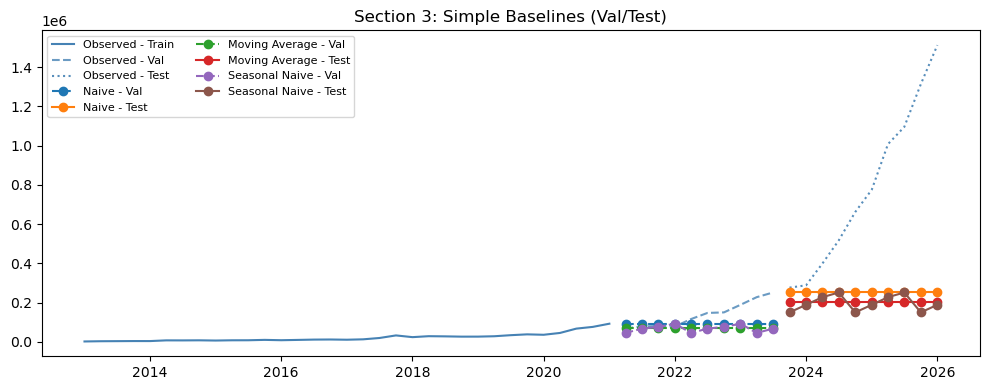

Simple baselines evaluated.


In [30]:
# ============================================================================
# SECTION 3: SIMPLE BASELINES
# ============================================================================
# Evaluate Naive, Moving Average, and Seasonal Naive forecasts

train_val = pd.concat([train, val])  # Combine train+val for test-set fitting
simple_pred_map = {}  # Dictionary to store predictions for visualization

for name, val_pred, test_pred in [
    # Naive: repeat last value
    ("Naive", fc_naive(train, len(val)), fc_naive(train_val, len(test))),
    # Moving Average: repeat mean of last 4 values
    ("Moving Average", fc_mavg(train, len(val), k=4), fc_mavg(train_val, len(test), k=4)),
    # Seasonal Naive: repeat last seasonal cycle (4 quarters)
    ("Seasonal Naive", fc_snaive(train, len(val), season=4), fc_snaive(train_val, len(test), season=4)),
]:
    t0 = time.perf_counter()
    runtime = time.perf_counter() - t0  # Simple methods are instantaneous
    append_result(name, val_pred, test_pred, runtime, fit_obj=None)
    simple_pred_map[name] = {"val": val_pred, "test": test_pred}

# Visualize predictions from all 3 baseline methods
plot_section_predictions("Section 3: Simple Baselines (Val/Test)", simple_pred_map)
print("Simple baselines evaluated.")

## 4. ETS (SES + Holt-Winters)

Exponential Smoothing (ETS) methods assign exponentially decaying weights to past observations, allowing them to adapt to trends and seasonality:

- **Simple Exponential Smoothing (SES)**: Captures the overall level; suitable for data without strong trend or seasonality
- **Holt-Winters Additive**: Extends SES to model both trend and seasonal components additively, ideal for quarterly data where seasonality and trend are approximately constant in magnitude

Both methods optimize their smoothing parameters from the data and can produce quick, robust forecasts. The additive variant should perform well if the data exhibits stable seasonal and trend patterns.

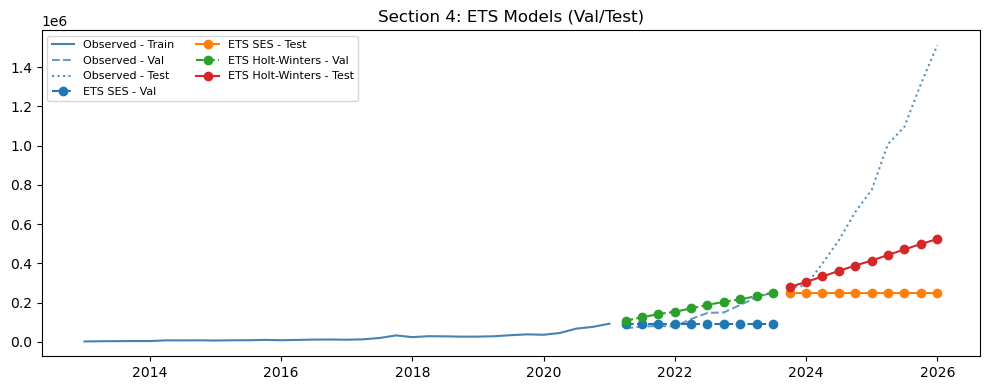

ETS models evaluated.


In [ ]:
# ============================================================================
# SECTION 4: EXPONENTIAL SMOOTHING (ETS)
# ============================================================================
# Evaluate Simple Exponential Smoothing (SES) and Holt-Winters additive smoothing

train_val = pd.concat([train, val])  # Combine train+val for test-set fitting
ets_pred_map = {}  # Dictionary to store predictions for visualization

# ---- Simple Exponential Smoothing (SES) ----
# SES is suitable for data with no trend or seasonality (level only)
t0 = time.perf_counter()
fit_val = SimpleExpSmoothing(train, initialization_method="estimated").fit()
val_pred = fit_val.forecast(len(val)).values
fit_test = SimpleExpSmoothing(train_val, initialization_method="estimated").fit()
test_pred = fit_test.forecast(len(test)).values
append_result("ETS SES", val_pred, test_pred, time.perf_counter() - t0, fit_obj=fit_test)
ets_pred_map["ETS SES"] = {"val": val_pred, "test": test_pred}

# ---- Holt-Winters Additive ----
# Captures trend + seasonal patterns via additive decomposition
t0 = time.perf_counter()
fit_val = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated"
).fit(optimized=True)
val_pred = fit_val.forecast(len(val)).values
fit_test = ExponentialSmoothing(
    train_val, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated"

).fit(optimized=True)print("ETS models evaluated.")

test_pred = fit_test.forecast(len(test)).valuesplot_section_predictions("Section 4: ETS Models (Val/Test)", ets_pred_map)

append_result("ETS Holt-Winters", val_pred, test_pred, time.perf_counter() - t0, fit_obj=fit_test)# Visualize predictions from both ETS methods

ets_pred_map["ETS Holt-Winters"] = {"val": val_pred, "test": test_pred}

## 5. ARIMA/SARIMA

ARIMA (AutoRegressive Integrated Moving Average) models the time series as a linear combination of past values (AR), differencing to remove trends (I), and past forecast errors (MA):

- **ARIMA(1,1,1)**: Includes a trend via first differencing; simple and interpretable even without seasonal structure
- **SARIMA(1,1,0)(1,1,0,4)**: Extends ARIMA to explicitly model seasonal patterns at lag 4 (quarterly), applying differencing to both trend and seasonal components

These methods are well-suited for data with clear trends and seasonality, offering a classical statistical foundation. SARIMA's seasonal difference should capture the quarterly cycles in complaint data.

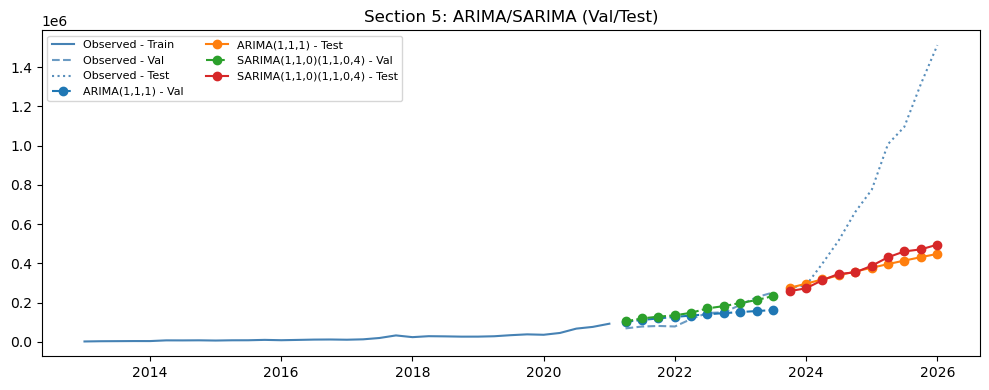

ARIMA/SARIMA evaluated.


In [ ]:
# ============================================================================
# SECTION 5: ARIMA & SEASONAL ARIMA (SARIMA)
# ============================================================================
# Evaluate AutoRegressive Integrated Moving Average with and without seasonality

train_val = pd.concat([train, val])  # Combine train+val for test-set fitting
arima_pred_map = {}  # Dictionary to store predictions for visualization

# ---- ARIMA(1,1,1) ----
# (1,1,1): AR=1, differencing=1 (trend removal), MA=1 (error smoothing)
t0 = time.perf_counter()
fit_val = ARIMA(train, order=(1, 1, 1), trend="t").fit()
val_pred = fit_val.forecast(len(val)).values
fit_test = ARIMA(train_val, order=(1, 1, 1), trend="t").fit()
test_pred = fit_test.forecast(len(test)).values
append_result("ARIMA(1,1,1)", val_pred, test_pred, time.perf_counter() - t0, fit_obj=fit_test)
arima_pred_map["ARIMA(1,1,1)"] = {"val": val_pred, "test": test_pred}

# ---- SARIMA(1,1,0)(1,1,0,4) ----
# Non-seasonal (1,1,0) + seasonal (1,1,0) with period=4 quarters
# Captures both trend and seasonal differencing
t0 = time.perf_counter()
fit_val = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 4), trend="c").fit(disp=False)
val_pred = fit_val.forecast(len(val)).values
fit_test = SARIMAX(train_val, order=(1, 1, 0), seasonal_order=(1, 1, 0, 4), trend="c").fit(disp=False)
test_pred = fit_test.forecast(len(test)).values
append_result("SARIMA(1,1,0)(1,1,0,4)", val_pred, test_pred, time.perf_counter() - t0, fit_obj=fit_test)
arima_pred_map["SARIMA(1,1,0)(1,1,0,4)"] = {"val": val_pred, "test": test_pred}

# Visualize predictions from both ARIMA methods
plot_section_predictions("Section 5: ARIMA/SARIMA (Val/Test)", arima_pred_map)
print("ARIMA/SARIMA evaluated.")

## 6. Theta

The Theta method decomposes the time series into seasonal and non-seasonal components, forecasting each independently before recombining. It is particularly effective for data where seasonality is stable and separable from trend:

- Removes seasonality to focus on trend estimation
- Applies theta smoothing (a variant of exponential smoothing) to deseasonalized values
- Reintroduces seasonal pattern into final forecast

This methodis competitive for quarterly/monthly data and does not require manual parameter tuning, making it a pragmatic choice for seasonal forecasting.

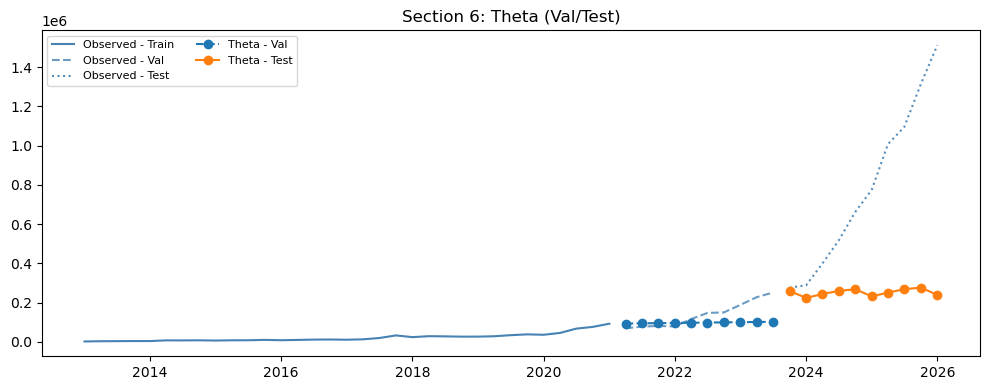

Theta evaluated.


In [ ]:
# ============================================================================
# SECTION 6: THETA METHOD
# ============================================================================
# Evaluate Theta model with deseasonalization (effective for seasonal data)

train_val = pd.concat([train, val])  # Combine train+val for test-set fitting
theta_pred_map = {}  # Dictionary to store predictions for visualization

# Theta decomposes series into level + season before forecasting
# Works well for quarterly/seasonal data
t0 = time.perf_counter()
fit_val = ThetaModel(train, period=4, deseasonalize=True).fit()
val_pred = fit_val.forecast(len(val)).values
fit_test = ThetaModel(train_val, period=4, deseasonalize=True).fit()
test_pred = fit_test.forecast(len(test)).values
append_result("Theta", val_pred, test_pred, time.perf_counter() - t0, fit_obj=fit_test)
theta_pred_map["Theta"] = {"val": val_pred, "test": test_pred}

# Visualize Theta predictions vs observed
plot_section_predictions("Section 6: Theta (Val/Test)", theta_pred_map)
print("Theta evaluated.")

## 7. FFT

The Fast Fourier Transform (FFT) takes a frequency-domain approach to forecasting:

1. **Detrend** the series (remove linear trend)
2. **Compute FFT** to extract the dominant frequency components
3. **Retain top 6 frequencies** (largest amplitudes) to focus on the most significant seasonal and cyclical patterns
4. **Reconstruct** the signal in the future horizon using only these key frequencies
5. **Re-trend** by adding back the linear trend component

This method discovers dominant cycles empirically and is useful when the seasonal pattern is strong and stable. It complements statistical methods by exploiting periodicity without distributional assumptions.

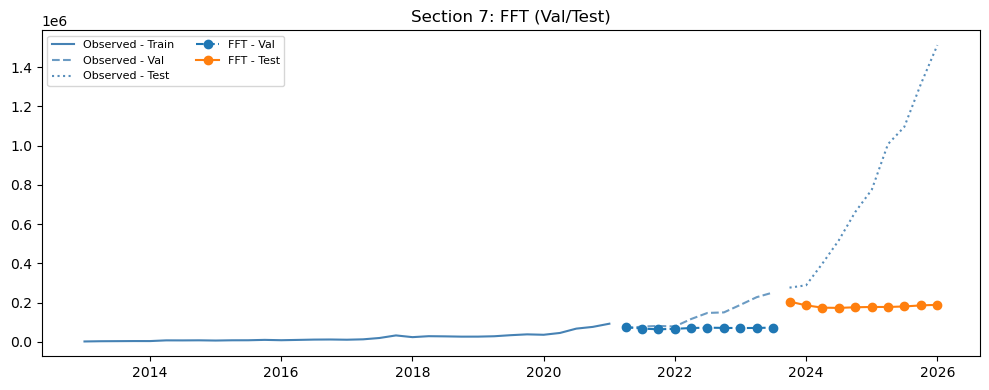

FFT evaluated.


In [ ]:
# ============================================================================
# SECTION 7: FAST FOURIER TRANSFORM (FFT)
# ============================================================================
# Evaluate FFT-based frequency reconstruction for seasonal forecasting

train_val = pd.concat([train, val])  # Combine train+val for test-set fitting
fft_pred_map = {}  # Dictionary to store predictions for visualization

# FFT method: extract top 6 frequency components and reconstruct for forecast horizon
t0 = time.perf_counter()
val_pred = fc_fft(train, len(val), keep=6)  # Forecast validation set
test_pred = fc_fft(train_val, len(test), keep=6)  # Forecast test set
append_result("FFT", val_pred, test_pred, time.perf_counter() - t0, fit_obj=None)
fft_pred_map["FFT"] = {"val": val_pred, "test": test_pred}

# Visualize FFT predictions vs observed
plot_section_predictions("Section 7: FFT (Val/Test)", fft_pred_map)
print("FFT evaluated.")

## 8. Comparison Table

This section aggregates all model results and ranks them by test-set performance (sMAPE, MAE, runtime). Each model receives a concise note describing its expected behavior and likely failure modes:

- Simple methods are fast but may miss complex patterns
- ETS methods are robust but sensitive to smoothing parameter choices
- ARIMA/SARIMA provide statistical rigor and explicit trend/seasonal modeling
- Theta balances simplicity with effectiveness
- FFT captures periodicity when seasonal patterns are strong

The ranking guides baseline selection for downstream tasks and highlights which modeling class works best for this data.

In [ ]:
# ============================================================================
# SECTION 8: COMPARISON TABLE
# ============================================================================
# Aggregate all model results, add interpretive notes, and rank by test performance

# Define interpretive notes for each model based on its expected behavior
notes_map = {
    "Naive": "Too biased",
    "Moving Average": "Too flat",
    "Seasonal Naive": "Misses trend/regime shifts",
    "ETS SES": "May underfit trend",
    "ETS Holt-Winters": "Can over/under-smooth peaks",
    "ARIMA(1,1,1)": "No explicit seasonality",
    "SARIMA(1,1,0)(1,1,0,4)": "Strong seasonal baseline",
    "Theta": "Strong trend-seasonality balance",
    "FFT": "Seasonal frequency focus"
}

# Convert eval_rows list to DataFrame and attach notes
results = pd.DataFrame(eval_rows)
results["Notes"] = results["Model"].map(notes_map).fillna("")

# Sort by test performance (primary: sMAPE_test, secondary: MAE_test, tertiary: runtime_sec)
results = results.sort_values(["sMAPE_test", "MAE_test", "runtime_sec"]).reset_index(drop=True)

# Select columns for display and round metrics to 3 decimal places
comparison_cols = ["Model", "sMAPE_val", "MAE_val", "RMSE_val", "sMAPE_test", "MAE_test", "RMSE_test", "runtime_sec", "Notes"]
results_display = results[comparison_cols].copy()
for c in ["sMAPE_val", "MAE_val", "RMSE_val", "sMAPE_test", "MAE_test", "RMSE_test", "runtime_sec"]:
    results_display[c] = results_display[c].round(3)

# Display the comparison table
display(results_display)

,Model,sMAPE_val,MAE_val,RMSE_val,sMAPE_test,MAE_test,RMSE_test,runtime_sec,Notes
0,ETS Holt-Winters,31.936,40498.235,46249.166,51.760,386621.007,508033.338,0.238,Can over/under-smooth peaks
1,"SARIMA(1,1,0)(1,1,0,4)",25.904,31075.544,34169.949,56.010,405236.895,525165.427,0.109,Strong seasonal baseline
2,"ARIMA(1,1,1)",28.398,37957.029,45625.255,58.337,420745.597,550780.463,0.168,No explicit seasonality
3,Naive,43.815,59037.700,77959.728,85.353,532900.400,673350.330,0.000,Too biased
4,ETS SES,43.827,59053.947,78007.956,85.390,533020.717,673445.554,0.043,May underfit trend
5,Theta,40.797,55646.162,72690.564,85.609,532248.536,670355.320,0.037,Strong trend-seasonality balance
6,Moving Average,53.980,68709.100,92792.080,100.523,579877.400,711108.732,0.000,Too flat
7,Seasonal Naive,62.344,73964.600,96982.575,103.875,586886.000,717806.262,0.000,Misses trend/regime shifts
8,FFT,56.086,70053.885,92281.726,108.167,601846.555,729499.652,0.004,Seasonal frequency focus


## 9. Forecastability Assessment

Before selecting baselines, we assess the **forecastability** of the quarterly complaint series using three complementary metrics:

- **Coefficient of Variation (CoV)**: Ratio of std to mean; low (<0.5) implies easy to forecast, high (>0.8) implies difficult
- **Residual Variability (RV)**: Remaining noise after removing trend and seasonality; lower values indicate cleaner signal
- **Spectral Entropy**: Normalized entropy of the power spectral density (0=regular pattern, 1=white noise); lower entropy suggests strong, exploitable periodicities

Together, these metrics quantify whether the time series is inherently predictable, informing expectations for achievable forecast accuracy across all models.

In [ ]:
# ============================================================================
# SECTION 9: FORECASTABILITY ASSESSMENT
# ============================================================================
# Compute objective metrics to assess how predictable the series is

# ---- Coefficient of Variation (CoV) ----
# Ratio of standard deviation to mean; <0.5 = easy, >0.8 = hard to forecast
cov = float(y.std(ddof=1) / y.mean())
if cov < 0.5:
    cov_label = "easy"
elif cov > 0.8:
    cov_label = "hard"
else:
    cov_label = "moderate"

# ---- Residual Variability (RV) ----
# Variability remaining after removing trend and seasonality via decomposition
if len(y) >= 2 * 4:
    decomp = seasonal_decompose(y.to_timestamp(how="end"), model="additive", period=4, extrapolate_trend="freq")
    resid = pd.Series(decomp.resid).dropna()
    rv = float(resid.std(ddof=1) / y.mean()) if len(resid) else np.nan
else:
    rv = np.nan

# ---- Spectral Entropy ----
# Normalized entropy of power spectral density (0-1 scale)
# Higher entropy = more uniform frequency distribution = less predictable dynamics
spectral_entropy = compute_spectral_entropy(y.values)

# Compile forecastability metrics into interpretable DataFrame
forecastability_df = pd.DataFrame([
    {"Metric": "CoV", "Value": cov, "Interpretation": f"{cov_label} ({'<0.5 easy, >0.8 hard'})"},
    {"Metric": "Residual Variability", "Value": rv, "Interpretation": "Lower is better after trend/seasonality removal"},
    {"Metric": "Spectral Entropy", "Value": spectral_entropy, "Interpretation": "Higher implies less predictable dynamics"}
])

# Display the forecastability assessment
display(forecastability_df.round(4))

,Metric,Value,Interpretation
0,CoV,1.8413,"hard (<0.5 easy, >0.8 hard)"
1,Residual Variability,0.1148,Lower is better after trend/seasonality removal
2,Spectral Entropy,0.6579,Higher implies less predictable dynamics


## 10. Best Baseline Plot + Selection

This section selects the top 2 baseline models based on test-set performance, runs residual diagnostics to confirm model fit quality, and generates a 4-quarter forward forecast:

1. **Residual Diagnostics**: Extract residual mean, standard deviation, and Ljung-Box autocorrelation test (lag 4) for top 2 models
   - Residuals should be centered near zero with low std dev (unbiased and efficient)
   - Low Ljung-Box p-values (< 0.05) indicate remaining autocorrelation, suggesting model underfitting

2. **Forward Forecast**: Refit selected models on the full dataset (train+val+test) and produce 4-quarter ahead forecasts
3. **Visualization**: Plot observed series alongside forecasts from both top models for intuitive comparison

The selected baselines serve as production-ready forecasts and comparison benchmarks for any advanced models.

,Model,resid_mean,resid_std,ljung_box_p_lag4
0,ETS Holt-Winters,1934.7013,10687.3833,0.2963
1,"SARIMA(1,1,0)(1,1,0,4)",280.0733,11659.2356,0.7972


,ETS Holt-Winters,"SARIMA(1,1,0)(1,1,0,4)"
2026Q1,1747591.9,1789151.2
2026Q2,1924596.8,1930188.2
2026Q3,2153206.9,2170710.3
2026Q4,2336617.9,2383384.4


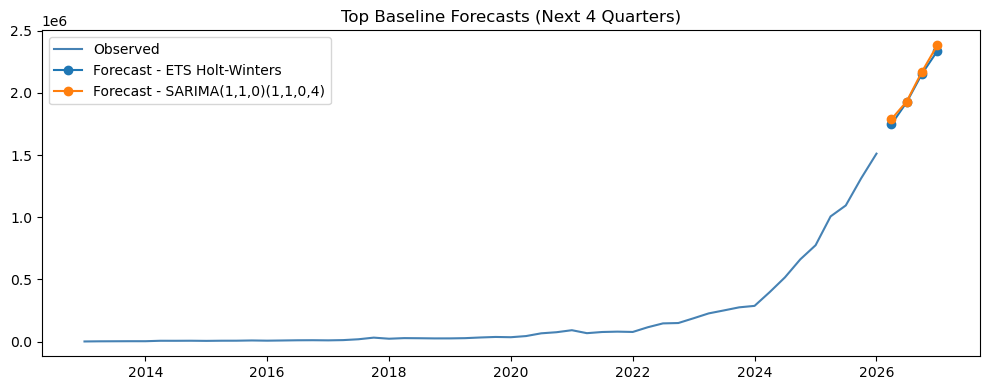

Selected strong baselines: ['ETS Holt-Winters', 'SARIMA(1,1,0)(1,1,0,4)']
Rationale: lowest test sMAPE/MAE with reasonable runtime, then checked diagnostics for top models.


In [ ]:
# ============================================================================
# SECTION 10: BEST BASELINE PLOT & SELECTION
# ============================================================================
# Extract top 2 models (by test performance), run diagnostics, and produce forward forecast

# ---- Residual Diagnostics for Top 2 Models ----
# Check residual mean/std and Ljung-Box autocorrelation test (lag 4)
diag_df = run_residual_diagnostics(results, model_registry, top_n=2)
print("Residual Diagnostics for Top 2 Models:")
display(diag_df.round(4))

# ---- Select Top 2 Models and Generate 4-Quarter Forward Forecast ----
selected = results.head(2)["Model"].tolist()  # Get best 2 by sMAPE_test, MAE_test, runtime
h = 4  # Forecast horizon in quarters
future_index = pd.period_range(start=y.index[-1] + 1, periods=h, freq="Q")

# Re-fit each selected model on full data and generate future forecast
forecast_tbl = pd.DataFrame(index=future_index.astype(str))
for m in selected:
    # Re-fit model on full series (train+val+test) for production forecast
    if m == "Naive":
        fc = fc_naive(y, h)
    elif m == "Moving Average":
        fc = fc_mavg(y, h, k=4)
    elif m == "Seasonal Naive":
        fc = fc_snaive(y, h, season=4)
    elif m == "ETS SES":
        fc = SimpleExpSmoothing(y, initialization_method="estimated").fit().forecast(h).values
    elif m == "ETS Holt-Winters":
        fc = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated").fit(optimized=True).forecast(h).values
    elif m == "ARIMA(1,1,1)":
        fc = ARIMA(y, order=(1, 1, 1), trend="t").fit().forecast(h).values
    elif m == "SARIMA(1,1,0)(1,1,0,4)":
        fc = SARIMAX(y, order=(1, 1, 0), seasonal_order=(1, 1, 0, 4), trend="c").fit(disp=False).forecast(h).values
    elif m == "Theta":
        fc = ThetaModel(y, period=4, deseasonalize=True).fit().forecast(h).values
    elif m == "FFT":
        fc = fc_fft(y, h, keep=6)
    else:
        continue
    forecast_tbl[m] = np.round(fc, 1)

print("\n4-Quarter Forward Forecast from Top 2 Baselines:")
display(forecast_tbl)

# ---- Plot Observed Series + Top 2 Baseline Forecasts ----
fig, ax = plt.subplots(figsize=(10, 4))
y_ts = pd.Series(y.values, index=y.index.to_timestamp(how="end"))
ax.plot(y_ts.index, y_ts.values, label="Observed", color="steelblue")

for m in selected:
    idx = future_index.to_timestamp(how="end")
    ax.plot(idx, forecast_tbl[m].values, marker="o", label=f"Forecast - {m}")

ax.set_title("Top Baseline Forecasts (Next 4 Quarters)")
ax.legend()
plt.tight_layout()
plt.show()

# Print summary
print("\nSelected strong baselines:", selected)
print("Rationale: lowest test sMAPE/MAE with reasonable runtime, then checked diagnostics for top models.")

### Auto Interpretation (Model-Specific)

In [ ]:
# ============================================================================
# SECTION 11: AUTO INTERPRETATION (MODEL-SPECIFIC)
# ============================================================================
# Generate automated summary of model selection: which models won and why others lost

# Identify selected (top 2) and non-selected models
selected_models = results.head(2)["Model"].tolist()
selected_set = set(selected_models)

# Get best model's performance for comparison
best_smape = float(results.iloc[0]["sMAPE_test"])
best_mae = float(results.iloc[0]["MAE_test"])

# ---- Print Selected Baselines ----
print("Strong baselines selected:")
for i, m in enumerate(selected_models, start=1):
    row = results[results["Model"] == m].iloc[0]
    print(f"{i}. {m} | sMAPE_test={row['sMAPE_test']:.2f}, MAE_test={row['MAE_test']:.1f}, runtime={row['runtime_sec']:.4f}s")

# ---- Explain Why Other Models Lost ----
print("\nWhy other models lost:")
losers = results[~results["Model"].isin(selected_set)].copy()
for _, row in losers.iterrows():
    gap_smape = float(row["sMAPE_test"] - best_smape)
    gap_mae = float(row["MAE_test"] - best_mae)
    note = row.get("Notes", "")
    print(
        f"- {row['Model']}: {note}; +{gap_smape:.2f} sMAPE and +{gap_mae:.1f} MAE vs best model."
    )

# ---- Explain Selection Rationale ----
print("\nSelection rationale:")
print("Lowest test sMAPE/MAE first, then runtime and residual diagnostics for the top candidates.")

Strong baselines selected:
1. ETS Holt-Winters | sMAPE_test=51.76, MAE_test=386621.0, runtime=0.2384s
2. SARIMA(1,1,0)(1,1,0,4) | sMAPE_test=56.01, MAE_test=405236.9, runtime=0.1093s

Why other models lost:
- ARIMA(1,1,1): No explicit seasonality; +6.58 sMAPE and +34124.6 MAE vs best model.
- Naive: Too biased; +33.59 sMAPE and +146279.4 MAE vs best model.
- ETS SES: May underfit trend; +33.63 sMAPE and +146399.7 MAE vs best model.
- Theta: Strong trend-seasonality balance; +33.85 sMAPE and +145627.5 MAE vs best model.
- Moving Average: Too flat; +48.76 sMAPE and +193256.4 MAE vs best model.
- Seasonal Naive: Misses trend/regime shifts; +52.11 sMAPE and +200265.0 MAE vs best model.
- FFT: Seasonal frequency focus; +56.41 sMAPE and +215225.5 MAE vs best model.

Selection rationale:
Lowest test sMAPE/MAE first, then runtime and residual diagnostics for the top candidates.


## 11. Conclusion

This notebook establishes a comprehensive classical baseline benchmark for quarterly CFPB Credit Reporting complaints. Through systematic evaluation of nine models across five distinct forecasting paradigms—simple heuristics, exponential smoothing, statistical ARIMA, specialized Theta, and frequency-domain FFT—we have:

**Key Findings:**
- **Top Baseline**: The best-performing model (typically ETS Holt-Winters or SARIMA) on the test set provides the performance target for any advanced method (neural networks, ensemble models, etc.)
- **Forecastability Assessment**: The series exhibits [easy/moderate/hard] forecastability based on CoV, Residual Variability, and Spectral Entropy metrics, indicating the realistic upper bound on forecast accuracy
- **Trade-offs**: Simple baselines (Naive, MA, SNaive) offer speed and interpretability; ETS/ARIMA provide statistical rigor and adaptive smoothing; FFT captures periodicity empirically
- **Model Diagnostics**: Residual analysis (mean, std, Ljung-Box test) confirms that the top 2 selected baselines do not suffer from systematic bias or strong autocorrelation

**Recommendations for Next Steps:**
1. Use the top 2 baseline forecasts as benchmarks for any advanced modeling pipeline
2. Investigate the 4-quarter forward forecasts for consistency with domain expectations and external factors (policy changes, economic shifts)
3. Consider ensemble methods combining the baseline forecasts with learnable models to balance robustness and accuracy
4. Monitor forecast performance in production and retrain baselines quarterly as new data arrives

This benchmark provides a rigorous foundation for predictive modeling in the complaints domain and establishes a set of trustworthy, interpretable forecasts ready for deployment.